In [1]:
import os
from typing import List
from typing import Sequence
from typing import Tuple

from torchvision.datasets import Omniglot
from torchvision import transforms
from torch.utils.data import DataLoader

import torch 
import numpy as np


In [1]:
import os
print(os.getcwd())

/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork


In [2]:
# Test TinyImageNet CIFAR-style dataloader
import torch
import matplotlib.pyplot as plt
from src.dataloaders.tinyimagenet import get  # <- your saved dataloader file

# --- Load the dataset ---
data, taskcla, size = get(seed=42, pc_valid=0.1, path='../dat/', num_tasks=40, classes_per_task=5)

print(f"Image size: {size}")
print(f"Number of tasks: {len(taskcla)}")
print(f"Classes per task: {taskcla[0][1]}")
print(f"Total classes across all tasks: {data['ncla']}")

# --- Inspect one task ---
task_id = 0
print(f"\nInspecting task {task_id} - {data[task_id]['name']}")
print(f"Train set: {data[task_id]['train']['x'].shape}")
print(f"Valid set: {data[task_id]['valid']['x'].shape}")
print(f"Test set: {data[task_id]['test']['x'].shape}")

# --- Visualize a few training samples from the first task ---
x = data[task_id]['train']['x']
y = data[task_id]['train']['y']
mean = torch.tensor([0.4802, 0.4481, 0.3975]).view(3,1,1)
std = torch.tensor([0.2302, 0.2265, 0.2262]).view(3,1,1)

fig, axes = plt.subplots(1, 5, figsize=(12,3))
for i, ax in enumerate(axes):
    img = x[i] * std + mean  # unnormalize
    img = img.permute(1,2,0).clamp(0,1)
    ax.imshow(img)
    ax.set_title(f"Class {y[i].item()}")
    ax.axis('off')
plt.show()

# --- Check class distribution for this task ---
unique, counts = torch.unique(y, return_counts=True)
print("Class distribution:", dict(zip(unique.tolist(), counts.tolist())))


Task order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/dataloaders/tinyimagenet.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data[i][s]['x'] = torch.load(os.path.join(d

FileNotFoundError: [Errno 2] No such file or directory: '../dat/binary_tinyimagenet/data0testx.bin'

In [2]:
download_dir = '../dat/omniglot'

In [6]:
train_data = Omniglot(download_dir,background=True,download=True,transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 9464212/9464212 [00:00<00:00, 97950427.99it/s]


Extracting ./data/omniglot/omniglot-py/images_background.zip to ./data/omniglot/omniglot-py


In [77]:
alphabet_name = train_data._characters[300].split('/')[0]
train_data._alphabets.index(alphabet_name)

10

In [89]:
import os
from torchvision.datasets import Omniglot
from torchvision.transforms import ToTensor
from PIL import Image

class OmniglotWithAlphabet(Omniglot):
    def __init__(self, root, background=True, transform=None, target_transform=None, download=False):
        super().__init__(root, background=background, transform=transform, target_transform=target_transform, download=download)

        self.num_alphabets = len(self._alphabets)

    def __getitem__(self, index: int):
        """
        Args:
            index (int): Index

        Returns:
            tuple: (image, target) where target is index of the target character class.
        """
        image_name, character_class = self._flat_character_images[index]
        image_path = os.path.join(self.target_folder, self._characters[character_class], image_name)
        alphabet_name = self._characters[character_class].split('/')[0]
        alphabet_label = self._alphabets.index(alphabet_name)
        image = Image.open(image_path, mode="r").convert("L")

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            character_class = self.target_transform(character_class)

        return image, character_class, alphabet_label
    

In [90]:
# Concatenate all images in the dataset
all_images = torch.cat([train_data[i][0].unsqueeze(0) for i in range(len(train_data))], dim=0)

# Calculate mean and standard deviation
mean = all_images.mean(dim=[0,2,3])
std = all_images.std(dim=[0,2,3])



In [91]:
print(f"Mean: {mean}, Standard Deviation: {std}")

Mean: tensor([0.9221]), Standard Deviation: tensor([0.2681])


In [92]:
mean.shape

torch.Size([1])

In [93]:
mean=[0.9221]
std=[0.2681]

# OMNIGLOT
dat={}
dat['train']=OmniglotWithAlphabet(download_dir,background=True,download=True,transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean,std)]))

Files already downloaded and verified


In [99]:
# Concatenate all images in the dataset
all_labels = [train_data[i][1] for i in range(len(train_data))]

In [3]:
import importlib

In [12]:
from dataloaders import omniglot
importlib.reload(omniglot)

<module 'dataloaders.omniglot' from '/pub/hofmann-scratch/glanzillo/gvcl_fork/src/dataloaders/omniglot.py'>

In [13]:
data, taskcla, size = omniglot.get(path='../dat/', resize=True)

Files already downloaded and verified
Files already downloaded and verified
Generating dataset files... (this may take a while)


100%|██████████| 6492/6492 [00:10<00:00, 619.22it/s]
/pub/hofmann-scratch/glanzillo/gvcl_fork/src/dataloaders/omniglot.py:124: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  data[t][s]['y']=torch.LongTensor(np.array(data[t][s]['y'],dtype=int)).view(-1)
/pub/hofmann-scratch/glanzillo/gvcl_fork/src/dataloaders/omniglot.py:125: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first

In [17]:
data[0]['test']['y'].unique()

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33])

In [63]:
data[7]['train']['x'].shape

torch.Size([462, 1, 28, 28])

In [89]:
data[2]['train']['y'].min()

tensor(63)

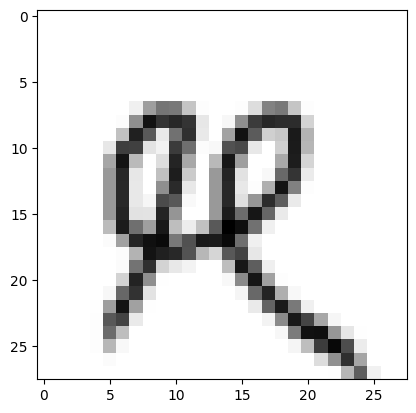

In [50]:

import matplotlib.pyplot as plt

plt.imshow(data[7]['train']['x'][200][0], cmap='gray')
plt.show()


In [57]:
from torchvision import transforms


In [77]:
training_alphabets= omniglot.OmniglotWithAlphabet(download_dir,background=True,download=True,transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize(omniglot.OmniglotWithAlphabet.mean,omniglot.OmniglotWithAlphabet.std)]), resize=(105,105))

Files already downloaded and verified


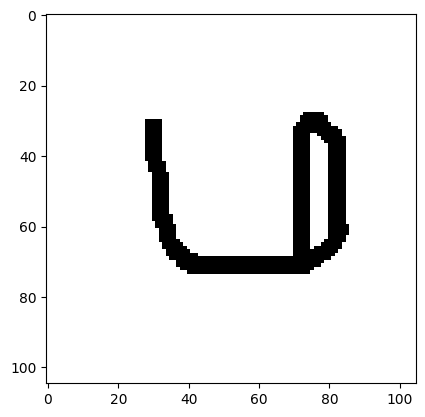

In [78]:

plt.imshow(training_alphabets[0][0][0], cmap='gray')
plt.show()

## Testing the loss

In [1]:
import sys,os,argparse,time
import numpy as np
import torch
from best_hyperparams import get_best_params, sweep_params

import utils
import setup
import random

In [2]:
from approaches import gvcl as approach
from dataloaders import cifar as dataloader
from networks.gvcl_models import ZenkeNetNoFiLM as network


In [3]:

tstart=time.time()
root_path = '../' #change to match running directory

random.seed(11)
np.random.seed(11)
torch.manual_seed(11)
if torch.cuda.is_available(): 
    torch.cuda.manual_seed(11)
else: print('[CUDA unavailable]'); sys.exit()


# Load
print('Load data...')
default_path = root_path+"dat/" #pick this otherwise
data,taskcla,inputsize=dataloader.get(seed=11, path=default_path)
print('Input size =',inputsize,'\nTask info =',taskcla)

Load data...
Task order = [0, 1, 2, 3, 4, 5]
Input size = [3, 32, 32] 
Task info = [(0, 10), (1, 10), (2, 10), (3, 10), (4, 10), (5, 10)]


In [4]:
# Inits
from argparse import Namespace


print('Inits...')
net=network.Net(inputsize,taskcla).cuda()
utils.print_model_report(net)

Inits...


----------------------------------------------------------------------------------------------------
Net(
  (conv_layers): ModuleList(
    (0): MFConvLayer(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MFConvLayer(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): MFConvLayer(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MFConvLayer(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_layers): ModuleList(
    (0): MFLinearLayer()
  )
  (heads): ModuleList(
    (0-5): 6 x MFLinearLayer()
  )
)
Dimensions = torch.Size([32, 3, 3, 3]) torch.Size([32]) torch.Size([32, 3, 3, 3]) torch.Size([32]) torch.Size([32, 32, 3, 3]) torch.Size([32]) torch.Size([32, 32, 3, 3]) torch.Size([32]) torch.Size([64, 32, 3, 3]) torch.Size([64]) torch.Size([64, 32, 3, 3]) torch.Size([64]) torch.Size([64, 64, 3, 3]) torch.Size([64]) torch.Size([64, 64, 3, 3]) torch.Size([64]) torch.Size([512, 4096]) torch.Size([512]) torch.Size([512, 4096

4388024

In [8]:
var_values

array([0.001     , 0.00215443, 0.00464159, 0.01      , 0.02154435,
       0.04641589, 0.1       , 0.21544347, 0.46415888, 1.        ])

In [11]:
np.logspace(-3, 0, num=4)

array([0.001, 0.01 , 0.1  , 1.   ])

In [9]:
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Initialize a list to store the sampled parameters
sampled_params = []
# Generate a list of variance values in linspace from 0 to 1
var_values = np.logspace(-3, 0, num=3)
# Sample the network parameters multiple times 
num_samples = 100
no_var = True # only sampling the mean parameters
mean=0

# Loop over each variance value
for var in var_values:
    # Loop over each sample
    for sample_idx in range(num_samples):
        # Sample the network parameters
        net.sample_parameters(mean=mean, variance=var, no_var=no_var)
        # Extract the parameters and flatten them
        params = torch.cat([p.flatten() for p in net.parameters()]).cpu().detach().numpy()
        # Store the parameters along with the variance and sample index
        sampled_params.append({'params': params, 'var': var, 'sample_idx': sample_idx})

# Convert the list to a DataFrame
params_df = pd.DataFrame(sampled_params)

# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
params_2d = pca.fit_transform(np.stack(params_df['params'].values))

# Add the PCA results to the DataFrame
params_df['pca1'] = params_2d[:, 0]
params_df['pca2'] = params_2d[:, 1]


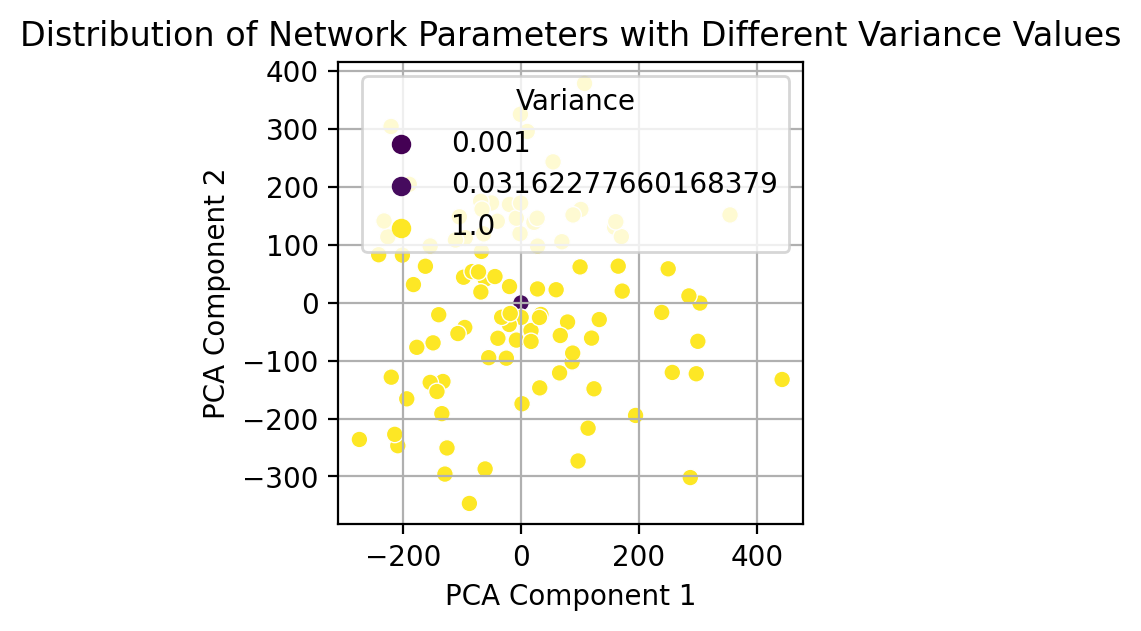

In [10]:

# Create a 2D visualization of the distribution of the network parameters
plt.figure(figsize=(3, 3), dpi=200)
sns.scatterplot(data=params_df, x='pca1', y='pca2', hue='var', palette='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Distribution of Network Parameters with Different Variance Values')
plt.legend(title='Variance')
plt.grid(True)
plt.show()

In [23]:

# Initialize a dataframe to store the results
results_df = pd.DataFrame()

In [24]:
# Generate a list of variance values in linspace from 0 to 1
var_values = np.logspace(-3, 0, num=4)
# Generate a list of q values in logspace from very close to 1 to 10
q_values = np.linspace(1 + 1e-6, 3-1e-6, num=100)
# Sample the network parameters multiple times for each q value
num_samples = 50
lamb = 1.0
v = 0.1
mean=0
no_var = True

#TODO: put the network in evaluation mode to see if anything changes

net.eval()

# Loop over each variance value
for var in var_values:
   # Loop over each q value
   for sample_idx in range(num_samples):
      net.sample_parameters(mean=mean, variance=var, no_var=no_var)
      for q in q_values:
         reg = net.get_reg(lamb=lamb, reg_type="re_g", q=q, v=v)
         reg_true = net.get_reg(lamb=lamb, reg_type="kl_g", q=q, v=v)
         results = pd.DataFrame({'q': q, 'reg': reg.item(), 'reg_true': reg_true.item(), 'sample_idx': sample_idx, 'var': var, 'no_var':no_var}, index=[0])
         results_df = pd.concat([results, results_df])

In [15]:
results_df['q'].unique()

array([2.99999900e+00, 2.97979700e+00, 2.95959500e+00, 2.93939300e+00,
       2.91919100e+00, 2.89898900e+00, 2.87878700e+00, 2.85858500e+00,
       2.83838300e+00, 2.81818100e+00, 2.79797900e+00, 2.77777700e+00,
       2.75757500e+00, 2.73737300e+00, 2.71717100e+00, 2.69696900e+00,
       2.67676700e+00, 2.65656500e+00, 2.63636300e+00, 2.61616100e+00,
       2.59595900e+00, 2.57575700e+00, 2.55555500e+00, 2.53535300e+00,
       2.51515100e+00, 2.49494900e+00, 2.47474700e+00, 2.45454500e+00,
       2.43434300e+00, 2.41414100e+00, 2.39393900e+00, 2.37373700e+00,
       2.35353500e+00, 2.33333300e+00, 2.31313100e+00, 2.29292900e+00,
       2.27272700e+00, 2.25252500e+00, 2.23232300e+00, 2.21212100e+00,
       2.19191900e+00, 2.17171700e+00, 2.15151500e+00, 2.13131300e+00,
       2.11111100e+00, 2.09090900e+00, 2.07070700e+00, 2.05050500e+00,
       2.03030300e+00, 2.01010100e+00, 1.98989900e+00, 1.96969700e+00,
       1.94949500e+00, 1.92929300e+00, 1.90909100e+00, 1.88888900e+00,
      

In [25]:
plot_df = results_df.copy()

In [26]:
plot_df['difference'] = plot_df['reg'] - plot_df['reg_true']

In [27]:
grouped_stats = plot_df.groupby(['q', 'var', 'no_var'])['difference'].agg(['mean', 'std']).reset_index()
print(grouped_stats)

            q    var  no_var         mean       std
0    1.000001  0.001    True -3266608.295  0.464807
1    1.000001  0.010    True -3266608.305  0.498185
2    1.000001  0.100    True -3266608.285  0.534546
3    1.000001  1.000    True -3266608.220  1.000816
4    1.020203  0.001    True -3286058.910  0.489064
..        ...    ...     ...          ...       ...
395  2.979797  1.000    True -3044515.950  1.744525
396  2.999999  0.001    True -3044643.610  0.455017
397  2.999999  0.010    True -3044631.555  0.455382
398  2.999999  0.100    True -3044511.460  0.461143
399  2.999999  1.000    True -3043310.050  1.638971

[400 rows x 5 columns]


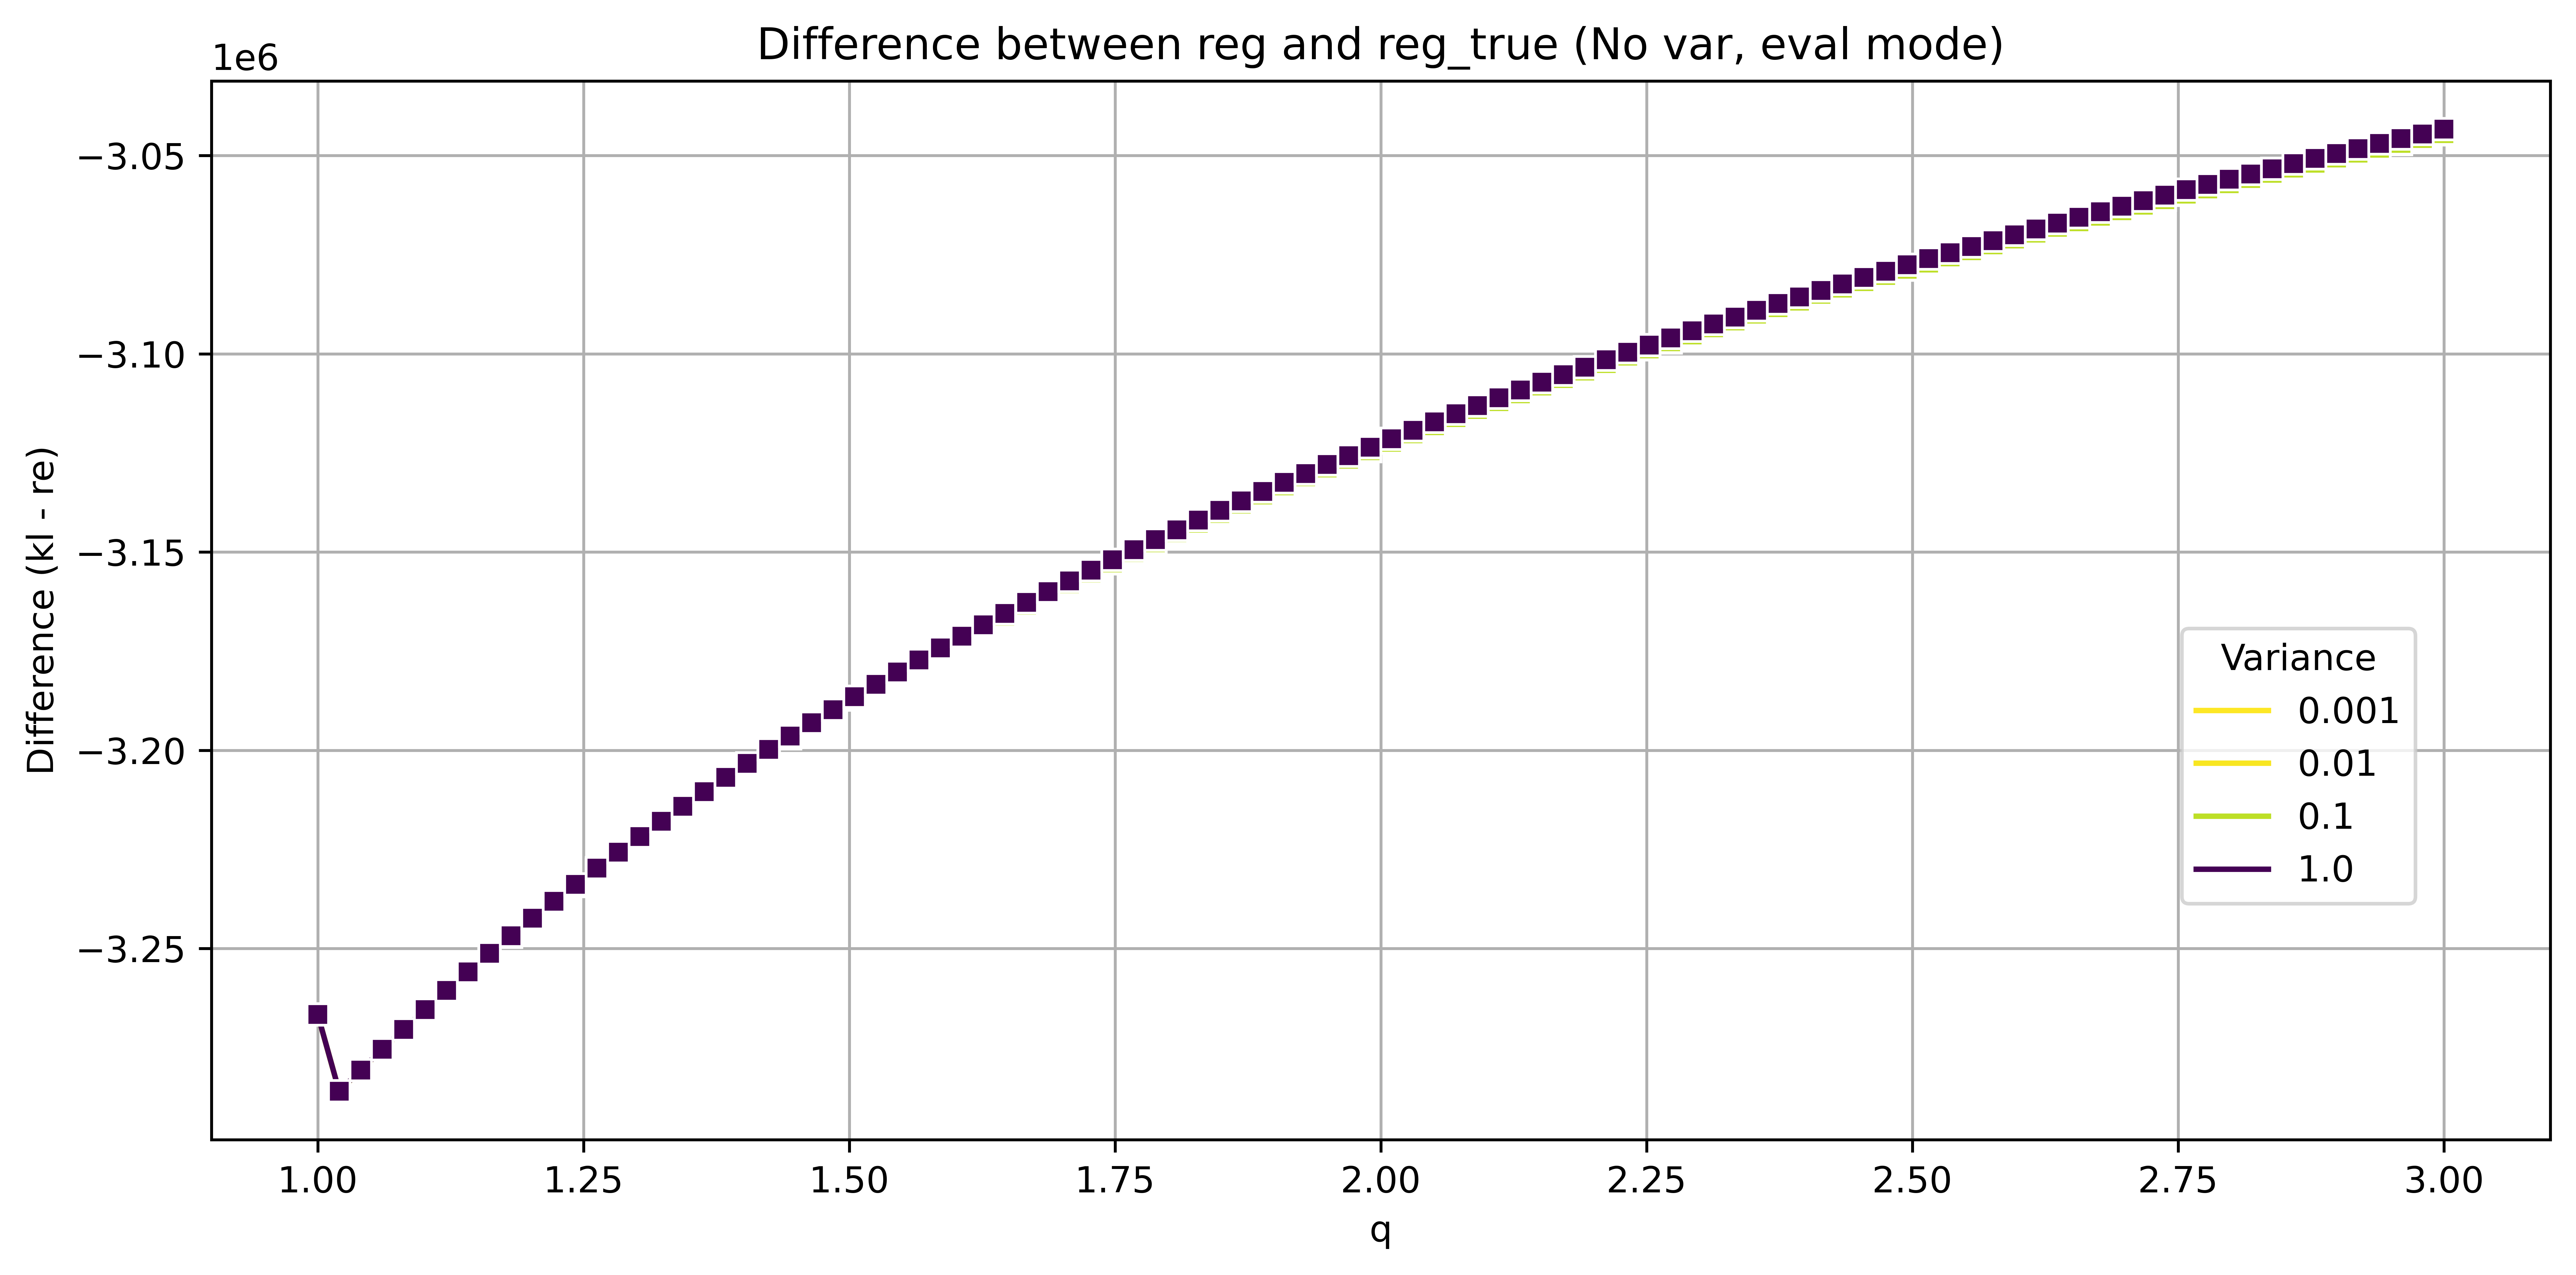

In [28]:
import seaborn as sns
# Calculate the difference between reg and reg_true
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=800, sharey=False)


# plt.yscale('symlog')
plot_df.dropna(subset=['difference'], inplace=True)
df_novar = plot_df.loc[plot_df['no_var']==True]
df_var = plot_df.loc[plot_df['no_var']==False]

# Plot for no_var=True
sns.lineplot(ax=ax, data=df_novar, x='q', y='difference', hue='var', marker='s', palette="viridis_r", errorbar=('sd', 10), linestyle='-')

ax.set_xlabel('q')
ax.set_ylabel('Difference (kl - re)')
ax.set_title('Difference between reg and reg_true (No var, eval mode)')
ax.grid(True)
ax.legend(title='Variance', bbox_to_anchor=(.95, 0.5))
#ax.set_xlim(1, 1.25)

plt.tight_layout()
plt.show()

In [117]:
plot_df

,q,reg,reg_true,sample_idx,var,no_var,difference
0,1.000001,2573185.75,2903199.00,9.0,1.0,False,330013.25
0,1.000001,2573069.00,2903188.25,8.0,1.0,False,330119.25
0,1.000001,2575599.75,2906314.75,7.0,1.0,False,330715.00
0,1.000001,2579097.50,2909473.75,6.0,1.0,False,330376.25
0,1.000001,2579360.25,2910767.25,5.0,1.0,False,331407.00
...,...,...,...,...,...,...,...
0,1.080809,3312516.75,6583037.00,0.0,0.0,True,3270520.25
0,1.060607,3307469.50,6583037.00,0.0,0.0,True,3275567.50
0,1.040405,3302289.50,6583037.00,0.0,0.0,True,3280747.50
0,1.020203,3296977.75,6583037.00,0.0,0.0,True,3286059.25


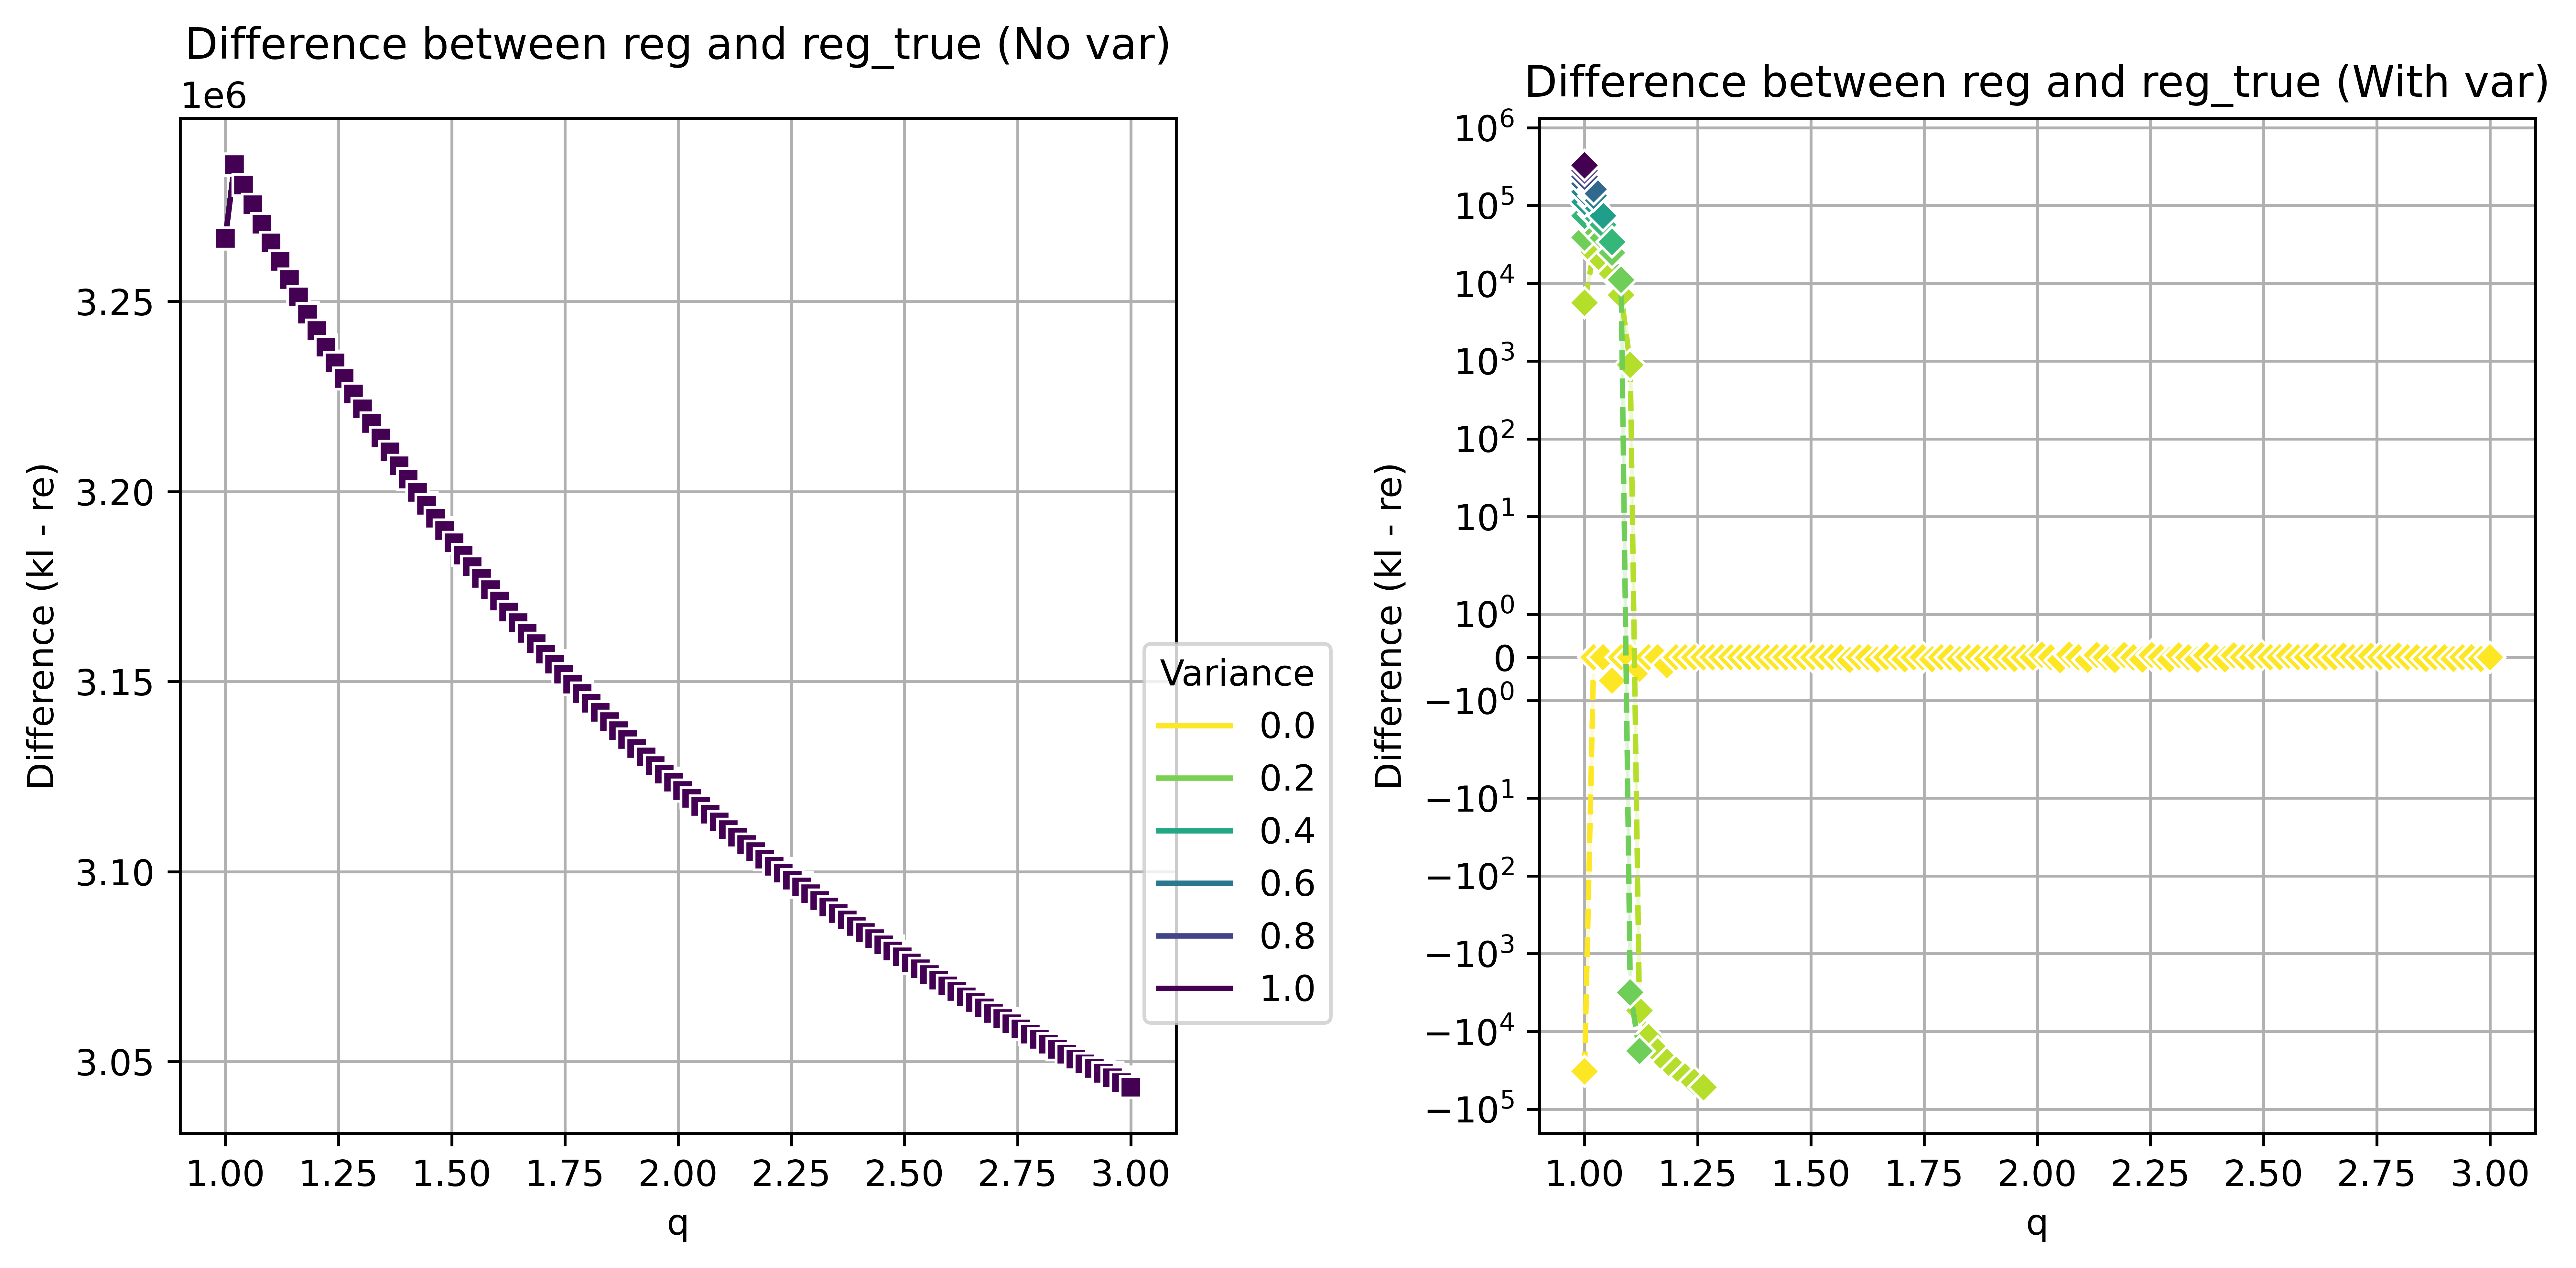

In [116]:
import seaborn as sns
# Calculate the difference between reg and reg_true
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=800, sharey=False)


plot_df.dropna(subset=['difference'], inplace=True)
# plt.yscale('symlog')
df_novar = plot_df.loc[plot_df['no_var']==True]
df_var = plot_df.loc[plot_df['no_var']==False]

# Plot for no_var=True
sns.lineplot(ax=axes[0], data=df_novar, x='q', y='difference', hue='var', marker='s', palette="viridis_r", errorbar=('sd', 10), linestyle='-')

axes[0].set_xlabel('q')
axes[0].set_ylabel('Difference (kl - re)')
axes[0].set_title('Difference between reg and reg_true (No var)')
axes[0].grid(True)
axes[0].legend(title='Variance', bbox_to_anchor=(.95, 0.5))

# Plot for no_var=False
sns.lineplot(ax=axes[1], data=df_var, x='q', y='difference', hue='var', marker='D', palette="viridis_r", errorbar=('sd', 10), linestyle='--')
axes[1].set_xlabel('q')
axes[1].set_ylabel('Difference (kl - re)')
axes[1].set_title('Difference between reg and reg_true (With var)')
axes[1].grid(True)
axes[1].set_yscale('symlog')
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

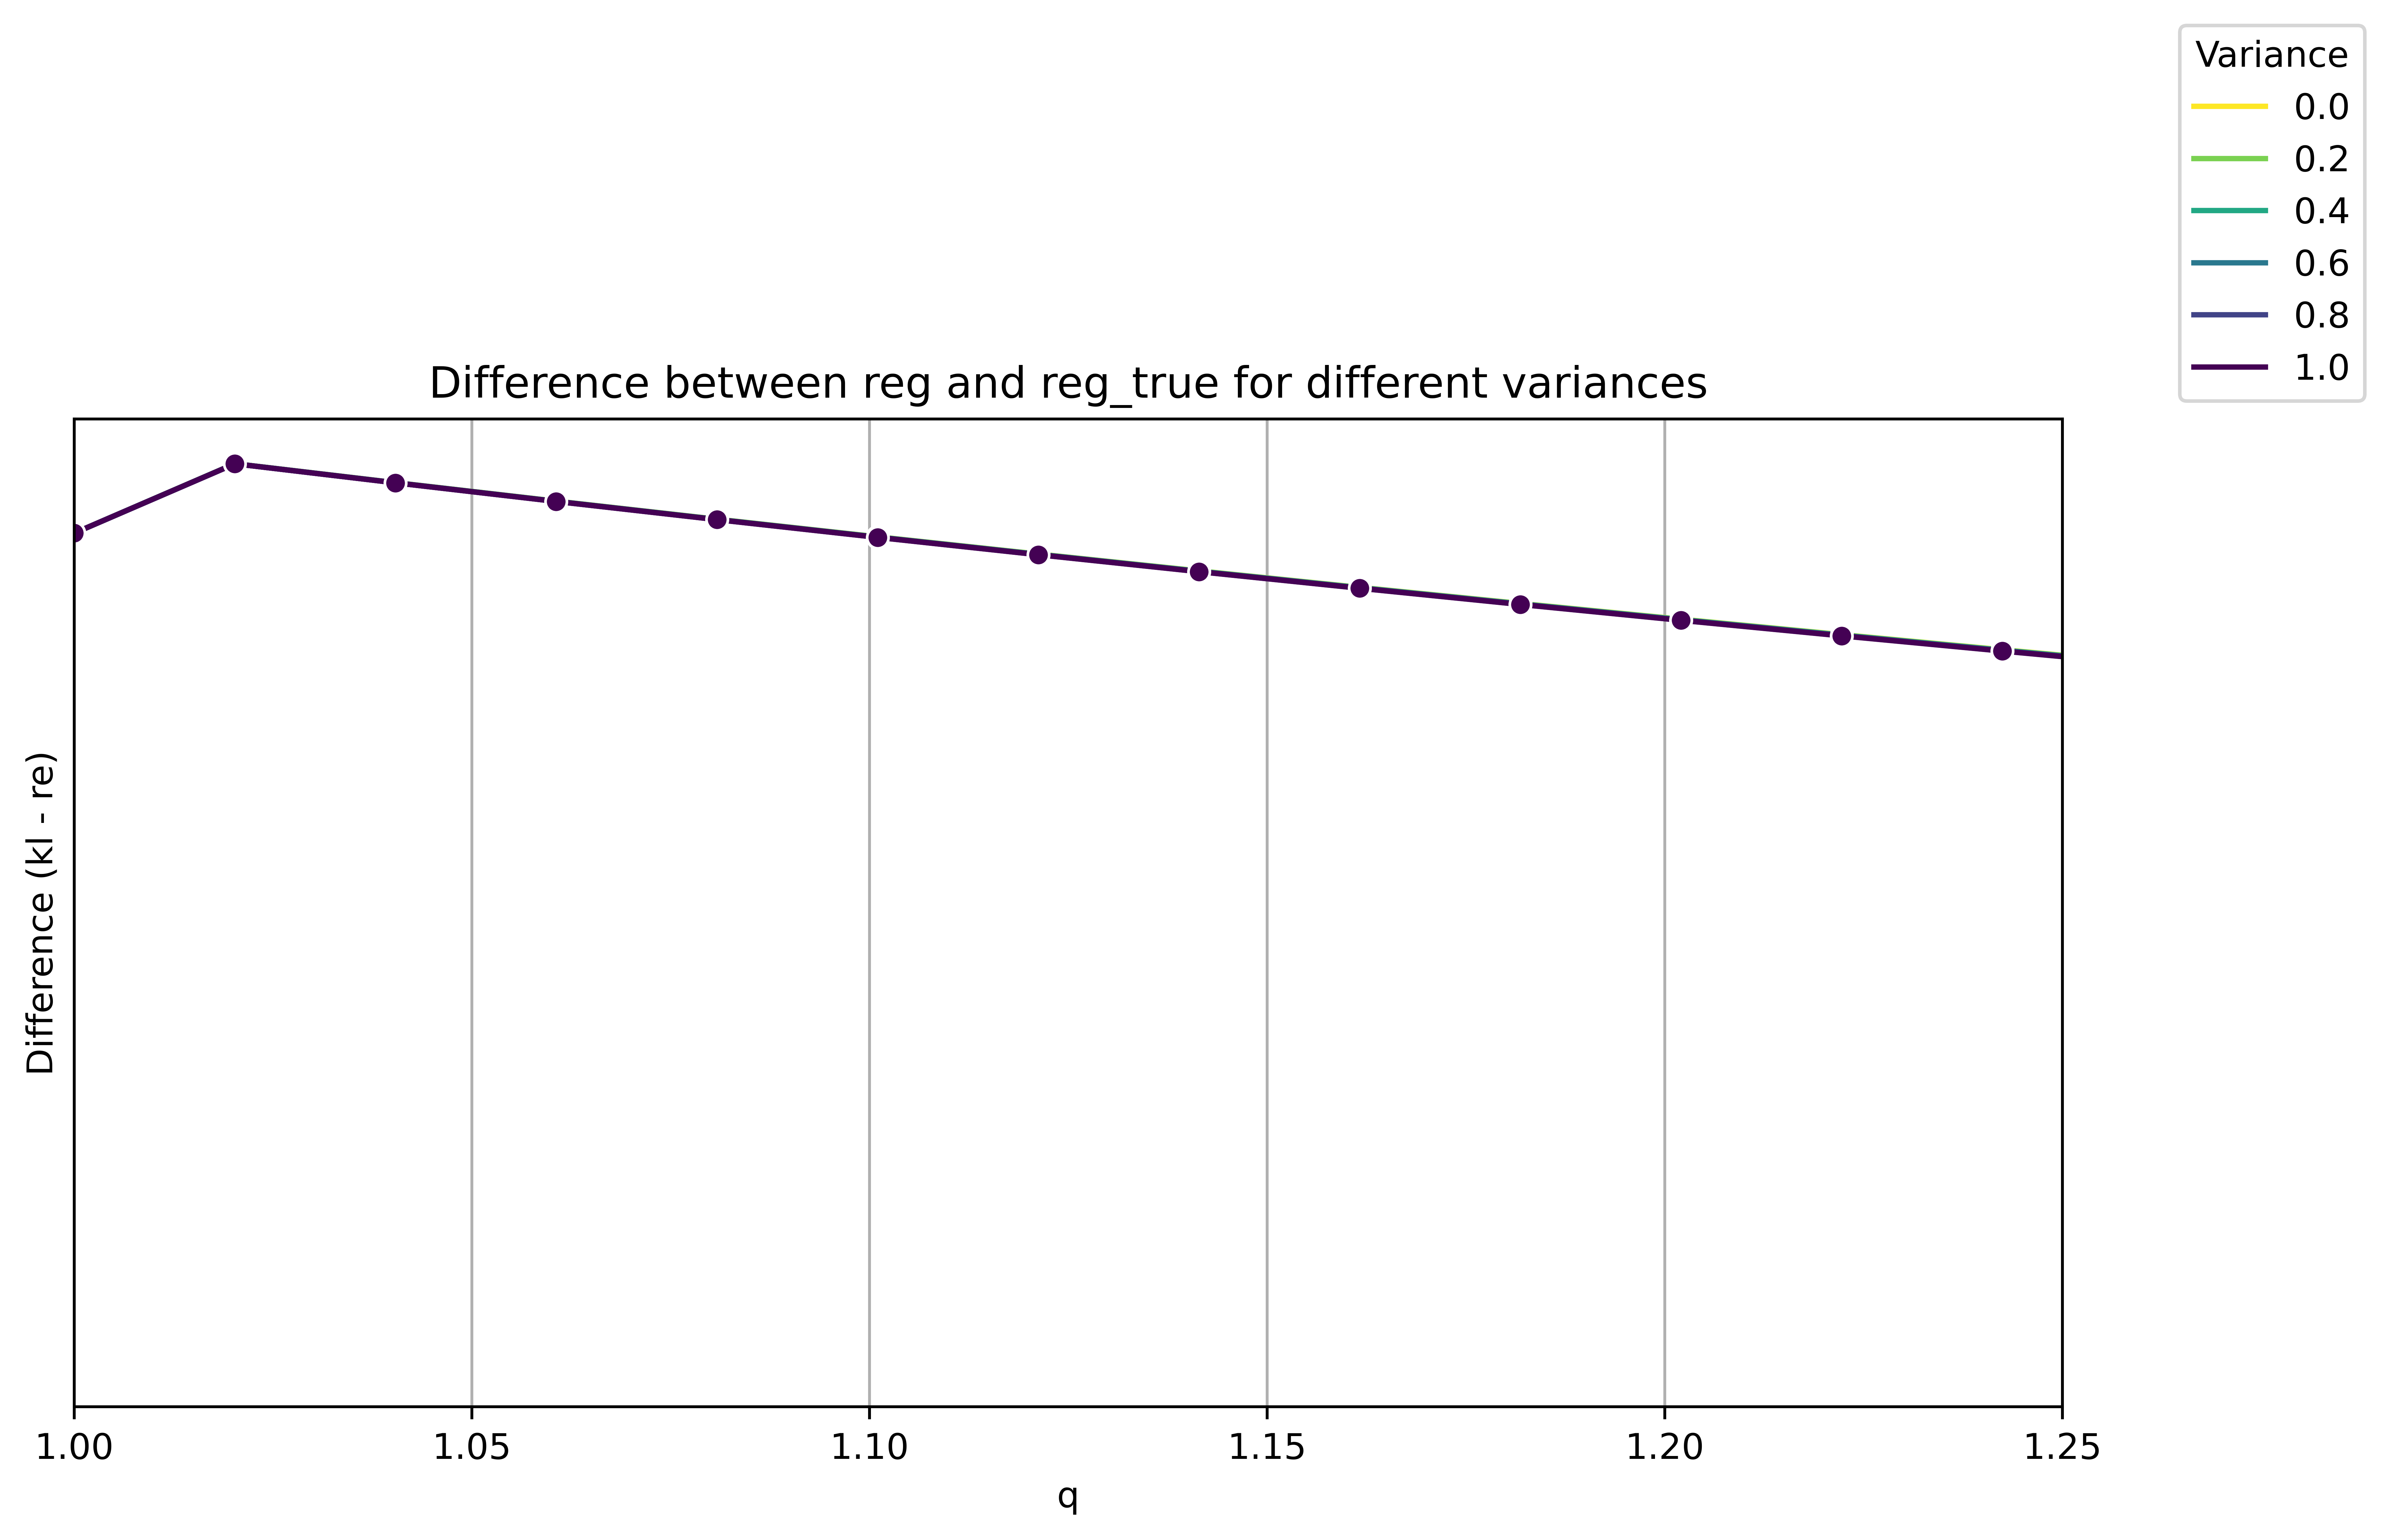

In [30]:
import seaborn as sns
# Calculate the difference between reg and reg_true
plot_df['difference'] = plot_df['reg_true'] - plot_df['reg']
# Plot the difference for different variances
plt.figure(figsize=(10, 5), dpi=800)
# Replace NaNs with 0 for plotting
plot_df.dropna(subset=['difference'], inplace=True)
plt.yscale('symlog')
plt.xlim(1, 1.25)
sns.lineplot(data=plot_df, x='q', y='difference', hue='var', marker='o', palette="viridis_r")
plt.xlabel('q')
plt.ylabel('Difference (kl - re)')
plt.title('Difference between reg and reg_true for different variances')
plt.grid(True)
plt.legend(title='Variance', bbox_to_anchor=(1.05, 1))
plt.show()